# Day 1-03｜Roboflow BBOX Homework
> Python 籃球運動資料分析課程  
> 本單元定義籃球偵測類別、Roboflow YOLO export 放置位置，並用已訓練 YOLO detector 檢查實際影片 frame。  
> 修課背景：具備基礎 Python 語法即可；不預設電腦視覺或運動資料分析經驗。

## 學習目標
- 建立 detection dataset 的類別規格與資料夾結構。
- 檢查 Roboflow YOLO detection export 是否可被 Ultralytics 讀取。
- 使用教師提供的 YOLO detector 權重產生實際偵測結果。

## 資料放置位置
- Roboflow YOLO detection export：`assets/datasets/roboflow_bbox_yolo/`
- 已訓練 detector 權重：`assets/models/detectors/yolo26n_basketball_player_best.pt`
- 學生自行上傳用圖片 zip：`assets/student_uploads/roboflow_bbox_student_upload_images.zip`


## 執行階段提醒
請優先使用 **GPU** 或 **TPU** 的執行階段；不要使用純 CPU 執行。  
YOLO、MediaPipe 與影片處理在純 CPU 上會明顯較慢，容易讓課堂操作卡住。


## 課程流程
1. 確認籃球偵測類別與 Roboflow export 結構。
2. 解壓 `assets/student_uploads/roboflow_bbox_student_upload_images.zip`，準備 5 張要上傳的 player detection 圖片。
3. 到 Roboflow 左側 side menu > `DATA` > `Upload Data`，把這 5 張圖片上傳到自己的 bbox 專案。
4. 接著到 side menu > `DATA` > `Annotate`，在 `Unassigned` 區塊點 `Annotate Images`，完成 bbox 標註。
5. 到 Roboflow 專案的 `Versions` 頁按 `Generate New Version` / `Publish`。
6. 把新的 `workspace slug`、`project slug`、`version number` 填回本 notebook。
7. 檢查 `assets/datasets/roboflow_bbox_yolo/`。
8. 閱讀實際訓練程式；預設不重新訓練。
9. 使用已訓練 detector 對參考影片 frame 執行推論。


In [1]:
from pathlib import Path
import subprocess
import sys

COURSE_ROOT_HINT = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "src" / "course_setup.py").exists()),
    Path("/content/basketball_hackathon/course"),
)
if not (COURSE_ROOT_HINT / "src" / "course_setup.py").exists() and "google.colab" in sys.modules:
    COURSE_ROOT_HINT.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run([
        "git", "clone", "--depth", "1", "https://github.com/henry753951/basketball-hackathon-course.git", str(COURSE_ROOT_HINT)
    ], check=True)
if str(COURSE_ROOT_HINT) not in sys.path:
    sys.path.insert(0, str(COURSE_ROOT_HINT))

from src.course_setup import bootstrap_course_repo  # noqa: E402

COURSE_ROOT = bootstrap_course_repo(COURSE_ROOT_HINT)


課程根目錄: H:\Repos\basketball-hackathon-course
素材資料夾: H:\Repos\basketball-hackathon-course\assets
工具模組: H:\Repos\basketball-hackathon-course\src


## Roboflow YOLO Detection Export 格式
Roboflow 匯出 YOLO 格式後，請將整個 dataset 放在：

```text
assets/datasets/roboflow_bbox_yolo/
├── data.yaml
├── train/ 或 images/train + labels/train
├── valid/ 或 images/valid + labels/valid
└── test/  或 images/test  + labels/test
```

本課程使用的 detector 類別與參考專案一致：`ball`、`ball-in-basket`、`number`、`player`、`player-in-possession`、`player-jump-shot`、`player-layup-dunk`、`player-shot-block`、`referee`、`rim`。

若學生是在 Roboflow 網頁上補標註，請先手動發布新的 dataset version；只有新 version 才能被下面的 API 下載流程抓到。


In [2]:
from getpass import getpass
from src.roboflow_utils import DETECTION_CLASSES, dataset_status, ensure_roboflow_detection_dataset

BBOX_DATASET_DIR = COURSE_ROOT / "assets" / "datasets" / "roboflow_bbox_yolo"
DETECTOR_MODEL_PATH = (
    COURSE_ROOT / "assets" / "models" / "detectors" / "yolo26n_basketball_player_best.pt"
)

# 學生作業建議流程：
# 1. 解壓 assets/student_uploads/roboflow_bbox_student_upload_images.zip。
# 2. 到 Roboflow 的 DATA > Upload Data 上傳 5 張圖片。
# 3. 到 DATA > Annotate，在 Unassigned 點 Annotate Images，完成 bbox 標註。
# 4. 到 Versions 頁面按 Generate New Version / Publish。
# 5. 把新的 workspace / project / version 填在下面。
# 6. 將 USE_ROBOFLOW_DOWNLOAD 改成 True。
USE_ROBOFLOW_DOWNLOAD = False
ROBOFLOW_WORKSPACE = "YOUR_WORKSPACE"
ROBOFLOW_PROJECT = "YOUR_PROJECT"
ROBOFLOW_VERSION = 1
ROBOFLOW_API_KEY = ""
FORCE_DOWNLOAD = False

if USE_ROBOFLOW_DOWNLOAD:
    api_key = ROBOFLOW_API_KEY or getpass("Roboflow API key: ")
    data_yaml = ensure_roboflow_detection_dataset(
        BBOX_DATASET_DIR,
        workspace=ROBOFLOW_WORKSPACE,
        project=ROBOFLOW_PROJECT,
        version=ROBOFLOW_VERSION,
        api_key=api_key,
        export_format="yolov8",
        overwrite=FORCE_DOWNLOAD,
    )
    print("ready data.yaml:", data_yaml)

for i, name in enumerate(DETECTION_CLASSES):
    print(i, name)

print("\\ndataset status:")
print(dataset_status(BBOX_DATASET_DIR))
print("\\nmodel exists:", DETECTOR_MODEL_PATH.exists(), DETECTOR_MODEL_PATH)


0 ball
1 ball-in-basket
2 number
3 player
4 player-in-possession
5 player-jump-shot
6 player-layup-dunk
7 player-shot-block
8 referee
9 rim
\ndataset status:
{'path': 'H:\\Repos\\basketball-hackathon-course\\assets\\datasets\\roboflow_bbox_yolo', 'exists': True, 'data_yaml': 'H:\\Repos\\basketball-hackathon-course\\assets\\datasets\\roboflow_bbox_yolo\\data.yaml', 'data_yaml_exists': False, 'splits': {}}
\nmodel exists: True H:\Repos\basketball-hackathon-course\assets\models\detectors\yolo26n_basketball_player_best.pt


In [3]:
RUN_TRAINING = False

if RUN_TRAINING:
    from ultralytics import YOLO

    data_yaml = BBOX_DATASET_DIR / "data.yaml"
    if not data_yaml.exists():
        raise FileNotFoundError(
            "找不到 data.yaml。請先將 Roboflow YOLO detection export 放到 assets/datasets/roboflow_bbox_yolo/"
        )

    model = YOLO("yolo26n.pt")
    results = model.train(
        data=str(data_yaml),
        epochs=20,
        imgsz=960,
        batch=2,
        workers=4,
        patience=30,
        close_mosaic=10,
        project=str(COURSE_ROOT / "assets" / "results" / "training" / "bbox_detection"),
        name="yolo26n_basketball_player",
        plots=True,
    )
    print(results)
else:
    print("RUN_TRAINING=False；本課程預設使用 assets/models/detectors/ 內的已訓練權重。")


RUN_TRAINING=False；本課程預設使用 assets/models/detectors/ 內的已訓練權重。


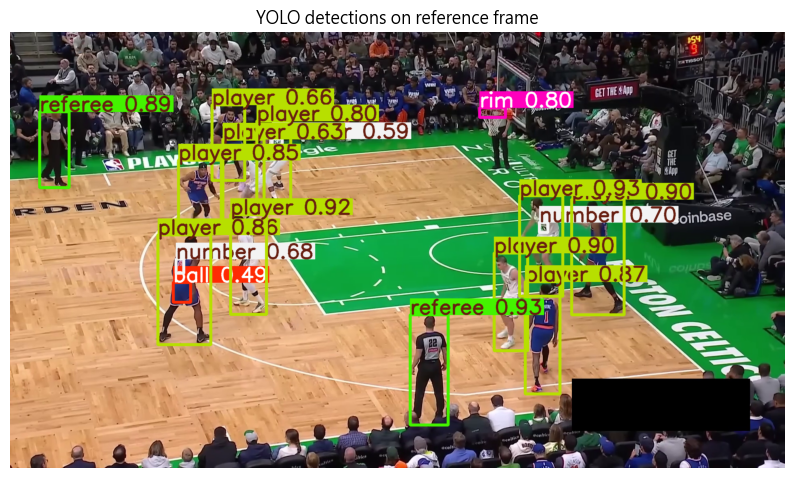

video: H:\Repos\basketball-hackathon-course\assets\raw\reference_videos\boston-celtics-new-york-knicks-game-1-q1-01.54-01.48.mp4
detections: 17
saved: H:\Repos\basketball-hackathon-course\assets\results\d1_03_yolo_detections.png


,frame_index,class_id,class_name,confidence,bbox_xyxy,track_id
0,15,3,player,0.934528,"[1262.403564453125, 405.6084899902344, 1369.75...",None
1,15,8,referee,0.928676,"[991.0457763671875, 700.4204711914062, 1085.69...",None
2,15,3,player,0.923289,"[546.931640625, 452.7513427734375, 635.5671386...",None
3,15,3,player,0.903542,"[1199.25537109375, 547.01025390625, 1282.00219...",None
4,15,3,player,0.898806,"[1391.5599365234375, 414.50311279296875, 1521....",None


In [4]:
import cv2
import pandas as pd
from ultralytics import YOLO

from src.cv_utils import save_image_rgb, save_json, show_image
from src.yolo_utils import detections_from_result

video_candidates = sorted((COURSE_ROOT / "assets" / "raw" / "reference_videos").glob("*.mp4"))
if not video_candidates:
    raise FileNotFoundError("找不到參考影片。請確認 assets/raw/reference_videos/ 內至少有一支 mp4。")

video_path = video_candidates[0]
cap = cv2.VideoCapture(str(video_path))
if not cap.isOpened():
    raise FileNotFoundError(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, 15)
ok, frame_bgr = cap.read()
cap.release()
if not ok:
    raise RuntimeError(f"無法讀取 frame 15: {video_path}")
frame = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

model = YOLO(str(DETECTOR_MODEL_PATH))
result = model.predict(frame, conf=0.25, imgsz=960, verbose=False)[0]
detections = detections_from_result(result, frame_index=15)
vis = result.plot().copy()
show_image(vis, "YOLO detections on reference frame")

out_image = COURSE_ROOT / "assets" / "results" / "d1_03_yolo_detections.png"
out_json = COURSE_ROOT / "assets" / "results" / "d1_03_yolo_detections.json"
save_image_rgb(out_image, vis)
save_json([record.__dict__ for record in detections], out_json)

print("video:", video_path)
print("detections:", len(detections))
print("saved:", out_image)
pd.DataFrame([record.__dict__ for record in detections]).head()


## 本單元產出檔案

- `assets/datasets/roboflow_bbox_yolo/data.yaml` 與對應 images / labels：Roboflow detection export。
- `assets/results/d1_03_yolo_detections.png`：單張 frame 的 YOLO detection 預覽圖。
- `assets/results/d1_03_yolo_detections.json`：單張 frame 的 detection 結果。
- 若 `RUN_TRAINING=True`，另外會產生 Ultralytics 訓練輸出目錄。
